In [3]:
%pip install tensorflow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached tensorflow_io_gcs_filesystem-0.31.0-cp310-cp310-win_amd64.whl.metadata (14 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached markdown_it_py-3.0.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/375.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/375.7 MB 4.8 MB/s eta 0:01:19
   ---------------------------------------- 1.8/375.7 MB 5.0 MB/s eta 0:01:15
   ---------------------------------------- 3.1/375.7 MB 5.9 MB/s eta 0:01:03
   ---------------------------------------- 4

# Simple MLP neural network without movie overview embeddings (user + movie input, rating output)
 

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf

In [2]:
df = pd.read_parquet("../datasets/full_train_dataset_with_embeddings.parquet")

In [3]:
df = pd.get_dummies(
    df,
    columns=["Gender"],
    dtype=np.float32,
)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 35 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   UserID             1000209 non-null  int64  
 1   MovieID            1000209 non-null  int64  
 2   Rating             1000209 non-null  int64  
 3   Timestamp          1000209 non-null  int64  
 4   Name               1000209 non-null  object 
 5   Action             1000209 non-null  int64  
 6   Adventure          1000209 non-null  int64  
 7   Animation          1000209 non-null  int64  
 8   Children's         1000209 non-null  int64  
 9   Comedy             1000209 non-null  int64  
 10  Crime              1000209 non-null  int64  
 11  Documentary        1000209 non-null  int64  
 12  Drama              1000209 non-null  int64  
 13  Fantasy            1000209 non-null  int64  
 14  Film-Noir          1000209 non-null  int64  
 15  Horror             1000209 non-n

In [5]:
from sklearn.calibration import LabelEncoder


le = LabelEncoder()
df["Zipcode_endcoded"] = le.fit_transform(df["Zip-code"])
df = df.drop(columns=["Zip-code"])

In [6]:
df["original_langage_encoded"] = le.fit_transform(df["original_language"])
df = df.drop(columns=["original_language"])

In [7]:
df["occupation_encoded"] = le.fit_transform(df["Occupation"])
df = df.drop(columns=["Occupation"])

In [ ]:
genre_cols = [
    "Action",
    "Adventure",
    "Animation",
    "Children's",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western",
    "adult",
]
numeric_cols = ["popularity", "vote_average", "vote_count", 'original_langage_encoded']
user_cols = [
    "UserID",
    "Age",
    "occupation_encoded",
    "Zipcode_endcoded",
    "Gender_M",
    "Gender_F",
]


In [ ]:
user_vecs = df[user_cols].to_numpy(dtype=np.float32)
item_vecs = df[genre_cols + numeric_cols].to_numpy(dtype=np.float32)
ratings = df["Rating"].to_numpy(dtype=np.float32)

In [ ]:
u_train, u_test, i_train, i_test, y_train, y_test = train_test_split(
    user_vecs, item_vecs, ratings, test_size=data.test_size, random_state=data.random_state
)

In [ ]:
user_dim = u_train.shape[1]  # =1
item_dim = i_train.shape[1]  # = len(genre_cols) + len(numeric_cols)
hidden = 128

inp_u = tf.keras.Input(shape=(user_dim,), name="user_input")
inp_i = tf.keras.Input(shape=(item_dim,), name="item_input")

# 2) Concatenate
x = tf.keras.layers.Concatenate()([inp_u, inp_i])

# 3) A deeper MLP stack
x = tf.keras.layers.Dense(512, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

x = tf.keras.layers.Dense(64, activation="relu")(x)
# you can add another Dropout/BatchNorm here if you like

x = tf.keras.layers.Dense(32, activation="relu")(x)

# 4) Final output
out = tf.keras.layers.Dense(1, name="rating")(x)

model = tf.keras.Model([inp_u, inp_i], out)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[tf.keras.metrics.RootMeanSquaredError()],
)

In [13]:
history = model.fit(
    x=[u_train, i_train],
    y=y_train,
    batch_size=256,
    epochs=50,
    validation_split=0.1,
    shuffle=True,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_root_mean_squared_error", patience=5, restore_best_weights=True
        )
    ],
)

Epoch 1/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 1.8039 - root_mean_squared_error: 1.3162 - val_loss: 1.4614 - val_root_mean_squared_error: 1.2089
Epoch 2/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 1.2800 - root_mean_squared_error: 1.1314 - val_loss: 1.2660 - val_root_mean_squared_error: 1.1252
Epoch 3/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 1.2581 - root_mean_squared_error: 1.1217 - val_loss: 1.2478 - val_root_mean_squared_error: 1.1171
Epoch 4/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 1.2519 - root_mean_squared_error: 1.1189 - val_loss: 1.2480 - val_root_mean_squared_error: 1.1171
Epoch 5/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 1.2512 - root_mean_squared_error: 1.1186 - val_loss: 1.2478 - val_root_mean_squared_error: 1.1170
Epoch 6/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 1.2510 - root_mean_squared_error: 1.1185 - val_loss: 1.2478 - val_root_mean_squared_error: 1.1171
Epoch 7/50
2814/2814 ━━━━━━━━━━━━━

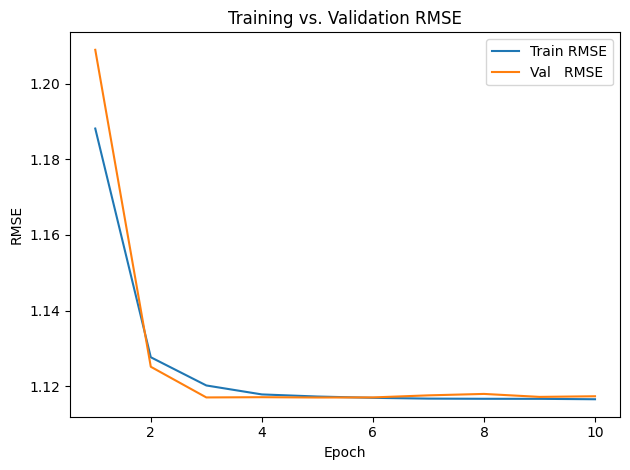

In [14]:
import matplotlib.pyplot as plt

# Assuming you have:
#   history = model.fit(...)

train_rmse = history.history["root_mean_squared_error"]
val_rmse = history.history["val_root_mean_squared_error"]
epochs = range(1, len(train_rmse) + 1)

plt.figure()
plt.plot(epochs, train_rmse, label="Train RMSE")
plt.plot(epochs, val_rmse, label="Val   RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training vs. Validation RMSE")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
train_rmse = history.history['root_mean_squared_error']
val_rmse = history.history['val_root_mean_squared_error']
print(f"Final Train RMSE: {train_rmse[-1]:.4f}")
print(f"Final Validation RMSE: {val_rmse[-1]:.4f}")

Final Train RMSE: 1.1166
Final Validation RMSE: 1.1174


In [ ]:
model.save("../models/mlp_without_overview/1/simple_mlp.keras")

In [18]:
model_json = model.to_json()
with open(
    "../models/mlp_without_overview/1/model_architecture.json", "w"
) as f:
    f.write(model_json)

In [20]:
model.save_weights("../models/mlp_without_overview/1/model.weights.h5")

In [33]:
user_dim = u_train.shape[1]  # =1
item_dim = i_train.shape[1]  # = len(genre_cols) + len(numeric_cols)
hidden = 128

inp_u = tf.keras.Input(shape=(user_dim,), name="user_input")
inp_i = tf.keras.Input(shape=(item_dim,), name="item_input")

# 2) Concatenate
x = tf.keras.layers.Concatenate()([inp_u, inp_i])

# 3) A deeper MLP stack
x = tf.keras.layers.Dense(512, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)

x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)

x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

x = tf.keras.layers.Dense(64, activation="relu")(x)
# you can add another Dropout/BatchNorm here if you like

x = tf.keras.layers.Dense(32, activation="relu")(x)

# 4) Final output
out = tf.keras.layers.Dense(1, name="rating")(x)

model = tf.keras.Model([inp_u, inp_i], out)

In [34]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[tf.keras.metrics.RootMeanSquaredError()],
)

In [35]:
history = model.fit(
    x=[u_train, i_train],
    y=y_train,
    batch_size=256,
    epochs=50,
    validation_split=0.1,
    shuffle=True,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_root_mean_squared_error", patience=5, restore_best_weights=True
        )
    ],
)

Epoch 1/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 1.7487 - root_mean_squared_error: 1.2987 - val_loss: 1.6319 - val_root_mean_squared_error: 1.2775
Epoch 2/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 1.2741 - root_mean_squared_error: 1.1288 - val_loss: 1.2509 - val_root_mean_squared_error: 1.1184
Epoch 3/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 1.2556 - root_mean_squared_error: 1.1205 - val_loss: 1.2529 - val_root_mean_squared_error: 1.1193
Epoch 4/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 1.2497 - root_mean_squared_error: 1.1179 - val_loss: 1.2479 - val_root_mean_squared_error: 1.1171
Epoch 5/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 1.2486 - root_mean_squared_error: 1.1174 - val_loss: 1.2491 - val_root_mean_squared_error: 1.1176
Epoch 6/50
2814/2814 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 1.2453 - root_mean_squared_error: 1.1159 - val_loss: 1.2482 - val_root_mean_squared_error: 1.1172
Epoch 7/50
2814/2814 ━━━━━━━━━━━━━